# Parcels environment : base

In [217]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def trans_vel_roms(u,v,angle):
    # np.cos(angle*np.pi/180)
    # np.sin(angle*np.pi/180)
    # when angle <0
    u_east=u*np.cos(angle*np.pi/180)-v*np.sin(angle*np.pi/180)
    v_north=u*np.sin(angle*np.pi/180)+v*np.cos(angle*np.pi/180)
    return u_east,v_north

def trans_AVISO2ROMS(ugo,vgo,angle):
    cost=np.cos(angle*np.pi/180)
    sint=np.sin(angle*np.pi/180)
    u_r=cost*ugo-sint*vgo
    v_r=sint*ugo+cost*vgo
    return u_r,v_r

from scipy.interpolate import griddata

def griddata_matlab(lona,lata,ugos,lon_rho,lat_rho):
    points = np.column_stack((lona.ravel(), lata.ravel()))
    values = ugos.ravel()
    
    # 步骤2: 创建目标网格点
    target_points = np.column_stack((lon_rho.ravel(), lat_rho.ravel()))
    
    # 步骤3: 执行插值
    ugos_interp = griddata(points, values, target_points, method='linear')
    
    # 步骤4: 重塑为原始网格形状
    ugos_interp = ugos_interp.reshape(lon_rho.shape)
    return ugos_interp

In [218]:
grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'
wave_dir='/meddy/simingzhang/Data/Parcels_data/'
# nowave_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/'
grdname='niskin2km_500m_grd.nc'
# hisname_w='z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# hisname_nw='z_niskin2km_his_smooth_depth_500m_grd.0002.nc'

grdname=f'{grid_dir}{grdname}'
# wavename=f'{wave_dir}{hisname_w}'
# nowavename=f'{nowave_dir}{hisname_nw}'

# wavename=f'{wave_dir}wavecase_modified_cg.nc'
# nowavename=f'{wave_dir}nowavecase_modified_cg.nc'
wavename=f'{wave_dir}wavecase_modified_cg_tukey1_Rodivofstrainof.nc'
nowavename=f'{wave_dir}nowavecase_modified_cg_tukey1_Rodivofstrainof.nc'

In [219]:
grid=xr.open_dataset(grdname)
grid = grid.swap_dims({'eta_u': 'eta_rho','xi_v':'xi_rho'})

lon_rho=grid['lon_rho']
lat_rho=grid['lat_rho']
h=grid['h']
angle=grid['angle'].values

lonmin=np.min(lon_rho.values)
lonmax=np.max(lon_rho.values)
latmin=np.min(lat_rho.values)
latmax=np.max(lat_rho.values)
lonmin,lonmax,latmin,latmax
grid

<xarray.Dataset> Size: 19MB
Dimensions:    (one: 1, eta_rho: 287, xi_rho: 287, bath: 1, xi_u: 286,
                eta_v: 286, eta_psi: 286, xi_psi: 286)
Dimensions without coordinates: one, eta_rho, xi_rho, bath, xi_u, eta_v,
                                eta_psi, xi_psi
Data variables: (12/34)
    xl         (one) float64 8B ...
    el         (one) float64 8B ...
    depthmin   (one) float64 8B ...
    depthmax   (one) float64 8B ...
    spherical  (one) |S1 1B ...
    angle      (eta_rho, xi_rho) float64 659kB -10.14 -10.14 ... -11.33 -11.33
    ...         ...
    lat_v      (eta_v, xi_rho) float64 657kB ...
    lat_psi    (eta_psi, xi_psi) float64 654kB ...
    mask_rho   (eta_rho, xi_rho) float64 659kB ...
    mask_u     (eta_rho, xi_u) float64 657kB ...
    mask_v     (eta_v, xi_rho) float64 657kB ...
    mask_psi   (eta_psi, xi_psi) float64 654kB ...
Attributes:
    title:    Solomon Model
    date:     08-Apr-2018
    type:     ROMS grid file

# AVISO

In [220]:
avisoname='/meddy/simingzhang/Data/Parcels_data/AVISO.nc'

In [221]:
av=xr.open_dataset(avisoname)

# del av
av

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 91, latitude: 64, longitude: 64)
Coordinates:
  * time       (time) datetime64[ns] 728B 2024-01-01 2024-01-02 ... 2024-03-31
  * latitude   (latitude) float32 256B 48.12 48.38 48.62 ... 63.38 63.62 63.88
  * longitude  (longitude) float32 256B -33.88 -33.62 -33.38 ... -18.38 -18.12
Data variables:
    sla        (time, latitude, longitude) float32 1MB ...
    ugos       (time, latitude, longitude) float32 1MB ...
    vgos       (time, latitude, longitude) float32 1MB ...
Attributes:
    Conventions:       CF-1.11
    title:             NRT merged all satellites Global Ocean Gridded SSALTO/...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2023-11-24 00:53:07Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_NRT_008_046
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P...
    subset:date:       2025-09-26T18:37:58.261Z

In [222]:
lona,lata = np.meshgrid(av['longitude'].values[1:-4], av['latitude'].values[1:-4])
dx1=u2rho_2d(spheric_dist(lata[:,1:], lata[:,:-1], lona[:,1:], lona[:,:-1]))
dy1=v2rho_2d(spheric_dist(lata[1:,:], lata[:-1,:], lona[1:,:], lona[:-1,:]))
pm=1./dx1
pn=1./dy1
sla=av['sla'].values[:,1:-4,1:-4]
ugos=av['ugos'].values[:,1:-4,1:-4]
vgos=av['vgos'].values[:,1:-4,1:-4]

In [223]:
np.min(av['longitude'].values[1:-4]),np.max(av['longitude'].values[1:-4]),np.min(av['latitude'].values[1:-4]),np.max(av['latitude'].values[1:-4])

(-33.625, -19.125, 48.375, 62.875)

In [224]:
pm=1/dx1
pn=1/dy1

In [225]:
# dx1[:,-1]
dx1.shape
dx=(dx1[np.newaxis,:,:])
dx.shape,sla.shape

((1, 59, 59), (91, 59, 59))

In [226]:
dx=np.tile(dx1[np.newaxis,:,:],[91,1,1])
dy=np.tile(dy1[np.newaxis,:,:],[91,1,1])
f=4*np.pi*np.sin(np.pi*lata/180)*366.25/(24*3600*365.25);

v=9.81*u2rho_3d((sla[:,:,1:]-sla[:,:,:-1])/(0.5*(dx[:,:,1:]+dx[:,:,:-1])))/np.tile(f[np.newaxis,:,:],[91,1,1])
u=-9.81*v2rho_3d((sla[:,1:,:]-sla[:,:-1,:])/(0.5*(dy[:,1:,:]+dy[:,:-1,:])))/np.tile(f[np.newaxis,:,:],[91,1,1])

In [227]:
vx=u2rho_3d((v[:,:,1:]-v[:,:,:-1])/(0.5*(dx[:,:,1:]+dx[:,:,:-1])))
uy=v2rho_3d((u[:,1:,:]-u[:,:-1,:])/(0.5*(dy[:,1:,:]+dy[:,:-1,:])))
Ro=(vx-uy)/np.tile(f[np.newaxis,:,:],[91,1,1])

# Plot AVISO

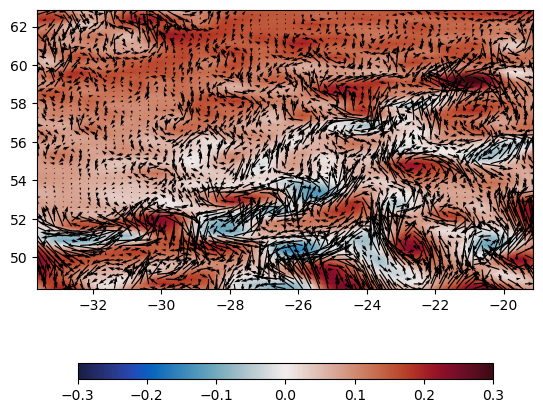

In [228]:
from cmocean import cm
tin=0
dot=1
# cs2=plt.pcolormesh(lona,lata,Ro[tin,:,:],shading='gouraud',cmap=cm.balance,vmin=-.5,vmax=.5)
cs2=plt.pcolormesh(lona,lata,sla[tin,:,:],shading='gouraud',cmap=cm.balance,vmin=-.3,vmax=.3)
colorbar1 = plt.colorbar(cs2, orientation='horizontal', pad=0.2, fraction=0.045, aspect=25)
plt.quiver(lona[::dot,::dot], lata[::dot,::dot], u[tin,::dot,::dot], v[tin,::dot,::dot], color='black', scale=5)
# plt.quiver(lona[::dot,::dot], lata[::dot,::dot], ugos[tin,::dot,::dot], vgos[tin,::dot,::dot], color='blue', scale=5)


In [229]:
np.max(sla)

0.352

# Interpolate to ROMS niskin

In [230]:
ugos_i=griddata_matlab(lona,lata,ugos[0,:,:],lon_rho.values,lat_rho.values)
vgos_i=griddata_matlab(lona,lata,vgos[0,:,:],lon_rho.values,lat_rho.values)
u_roms,v_roms=trans_AVISO2ROMS(ugos_i,vgos_i,abs(angle))

In [231]:
# ugos_i.shape
abs(angle)

array([[10.144763  , 10.14424865, 10.14373099, ...,  9.86950176,
         9.8680892 ,  9.86667364],
       [10.14971977, 10.14920457, 10.14868606, ...,  9.8741649 ,
         9.87275114,  9.87133437],
       [10.15467986, 10.15416381, 10.15364445, ...,  9.87883104,
         9.87741608,  9.87599811],
       ...,
       [11.69125505, 11.69045322, 11.68964766, ..., 11.31882587,
        11.31702098, 11.31521278],
       [11.69721258, 11.69640956, 11.6956028 , ..., 11.32438754,
        11.32258108, 11.3207713 ],
       [11.70317384, 11.70236963, 11.70156168, ..., 11.32995255,
        11.32814451, 11.32633315]])

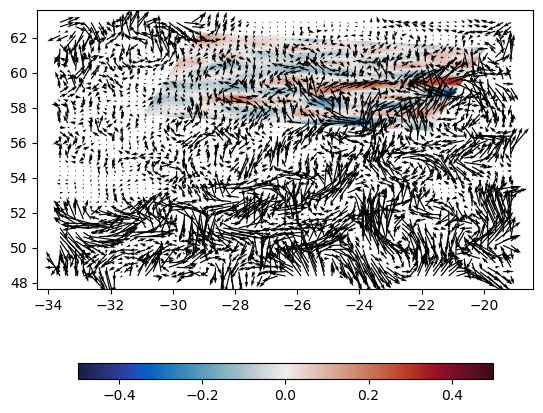

In [232]:
cs2=plt.pcolormesh(lon_rho.values,lat_rho.values,ugos_i,shading='gouraud',cmap=cm.balance,vmin=-.5,vmax=.5)
colorbar1 = plt.colorbar(cs2, orientation='horizontal', pad=0.2, fraction=0.045, aspect=25)
plt.quiver(lona[::dot,::dot], lata[::dot,::dot], u[tin,::dot,::dot], v[tin,::dot,::dot], color='black', scale=5)

In [233]:
ugos_i=np.zeros((91,287,287))
vgos_i=np.zeros((91,287,287))
u_roms=np.zeros((91,287,287))
v_roms=np.zeros((91,287,287))
# ugos_i=np.zeros((91,59,59))
# vgos_i=np.zeros((91,59,59))
# u_roms=np.zeros((91,59,59))
# v_roms=np.zeros((91,59,59))
# ugos_i=u
# vgos_i=v
from tqdm import tqdm
for tt in tqdm(range(91)):
    ugos_i[tt,:,:]=griddata_matlab(lona,lata,u[tt,:,:],lon_rho.values,lat_rho.values)
    vgos_i[tt,:,:]=griddata_matlab(lona,lata,v[tt,:,:],lon_rho.values,lat_rho.values)
    u_roms[tt,:,:],v_roms[tt,:,:]=trans_AVISO2ROMS(ugos_i[tt,:,:],vgos_i[tt,:,:],abs(angle))
    


100%|████████████████████████████████████████████████████████████| 91/91 [00:04<00:00, 18.30it/s]


In [234]:
# tin=10
# cs2=plt.pcolormesh(lon_rho.values,lat_rho.values,ugos_i[tin,:,:],shading='gouraud',cmap=cm.balance,vmin=-.5,vmax=.5)
# colorbar1 = plt.colorbar(cs2, orientation='horizontal', pad=0.2, fraction=0.045, aspect=25)
# plt.quiver(lona[::dot,::dot], lata[::dot,::dot], u[tin,::dot,::dot], v[tin,::dot,::dot], color='black', scale=5)

In [235]:
# u_roms=ugos_i
# v_roms=vgos_i

In [236]:
ur=0.5*(u_roms[:,:,1:]+u_roms[:,:,:-1])
vr=0.5*(v_roms[:,1:,:]+v_roms[:,:-1,:])

In [237]:
# np.arange(91)*86400


In [238]:
vr.shape

(91, 286, 287)

In [239]:
# 设置网格尺寸
xi_rho = 287
xi_u = 286
eta_rho = 287
eta_v = 286
depth_size = 1
time_size = 91  # 您指定的时间维度大小
import pandas as pd
# xi_rho = 59
# xi_u = 58
# eta_rho = 59
# eta_v = 58
# depth_size = 1
# time_size = 91  # 您指定的时间维度大小
# import pandas as pd

# 创建时间坐标 - 假设从 2000-01-01 开始，每天一个时间步
# start_date = '2000-01-01'
# time_coords = np.arange(91)
# ocean_time=time_coords*86400
start_date = '2000-01-01'
time_coords = pd.date_range(start=start_date, periods=time_size, freq='D')

# 创建 ocean_time 变量
ocean_time = (time_coords - pd.Timestamp(start_date)).total_seconds()
# 创建深度坐标 - 假设只有一个深度层 500m
depth_coords = np.array([-2])


# 创建 xarray Dataset
ds = xr.Dataset(
    {
        "u": (["time", "depth", "eta_rho", "xi_u"], ur[:,np.newaxis,:,:], {
            "long_name": "u-momentum component",
            "units": "meter second-1",
            "standard_name": "sea_water_x_velocity_at_u_location",
            "coordinates": "lat_u lon_u",
            "_FillValue": 1.e+33
        }),
        "v": (["time", "depth", "eta_v", "xi_rho"], vr[:,np.newaxis,:,:], {
            "long_name": "v-momentum component",
            "units": "meter second-1",
            "standard_name": "sea_water_y_velocity_at_v_location",
            "coordinates": "lat_v lon_v",
            "_FillValue": 1.e+33
        }),
        "ocean_time": (["time"], ocean_time, {
            "long_name": "ocean_time",
            "units": "seconds",
        }),
        #  "pm": (["eta_rho", "xi_rho"], pm, {
        #     "long_name": "1 over dx",
        #     "_FillValue": 1.e+33
        # }),
        # "pn": (["eta_rho", "xi_rho"], pn, {
        #     "long_name": "1 over dy",
        #     "_FillValue": 1.e+33
        # }),
        # "f": (["eta_rho", "xi_rho"], f, {
        #     "long_name": "corilios frequency",
        #     "_FillValue": 1.e+33
        # }),
    },
    coords={
        "time": (["time"], time_coords, {
            "long_name": "time since initialization",
            "standard_name": "time",
            "axis": "T"
        }),
        "depth": (["depth"], depth_coords, {
            "long_name": "depth",
            "units": "meters",
            "positive": "down"
        }),
        "lon_rho": (["eta_rho", "xi_rho"], lon_rho.values, {"long_name": "longitude of rho-points"}),
        "lat_rho": (["eta_rho", "xi_rho"], lat_rho.values, {"long_name": "latitude of rho-points"}),
        # "lon_u": (["xi_u"], lon_u, {"long_name": "longitude of u-points"}),
        # "lat_u": (["eta_rho"], lat_rho, {"long_name": "latitude of u-points"}),  # 注意u点的纬度与rho点相同
        # "lon_v": (["xi_rho"], lon_rho, {"long_name": "longitude of v-points"}),    # 注意v点的经度与rho点相同
        # "lat_v": (["eta_v"], lat_v, {"long_name": "latitude of v-points"})
    },
    attrs={
        "title": "AVISO to ROMS niskin Output",
        "institution": "Your Institution",
        "source": "AVISO",
        "history": f"Created on {pd.Timestamp.now().isoformat()}",
        "Conventions": "CF-1.8"
    }
)




In [240]:
ds

<xarray.Dataset> Size: 121MB
Dimensions:     (time: 91, depth: 1, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * time        (time) datetime64[ns] 728B 2000-01-01 2000-01-02 ... 2000-03-31
  * depth       (depth) int64 8B -2
    lon_rho     (eta_rho, xi_rho) float64 659kB -30.93 -30.89 ... -19.99 -19.95
    lat_rho     (eta_rho, xi_rho) float64 659kB 57.6 57.59 57.59 ... 61.39 61.38
Dimensions without coordinates: eta_rho, xi_u, eta_v, xi_rho
Data variables:
    u           (time, depth, eta_rho, xi_u) float64 60MB 0.01101 ... 0.03382
    v           (time, depth, eta_v, xi_rho) float64 60MB -0.03519 ... 0.03987
    ocean_time  (time) float64 728B 0.0 8.64e+04 ... 7.69e+06 7.776e+06
Attributes:
    title:        AVISO to ROMS niskin Output
    institution:  Your Institution
    source:       AVISO
    history:      Created on 2025-09-27T00:42:46.246856
    Conventions:  CF-1.8

In [241]:
ds["u_rho"] = (("time", "depth", "eta_rho", "xi_rho"), ugos_i[:,np.newaxis,:,:])
ds["v_rho"] = (("time", "depth", "eta_rho", "xi_rho"), vgos_i[:,np.newaxis,:,:])


In [242]:
wave_dir

'/meddy/simingzhang/Data/Parcels_data/'

In [243]:
ds.to_netcdf(f'/meddy/simingzhang/Data/RB_iceland_data/AVISO_niskin2km.0002.nc')

In [244]:
# ! cdo merge /meddy/simingzhang/Data/RB_iceland_data/AVISO_niskin2km.0002.nc /meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_aviso.0002.nc /meddy/simingzhang/Data/Parcels_data/AVISO_cg.nc

In [195]:
wavename=f'{wave_dir}AVISO_cg.nc'

In [196]:
ds1=xr.open_dataset(wavename)

In [197]:
lon_rho=ds1['lon_rho']
lat_rho=ds1['lat_rho']

# Parcel
### 1. wave case

In [245]:
wavename
# filenames = {"U": wavename, "V": wavename,"PI2": wavename,"PI4": wavename,"PI6": wavename,"PI8": wavename,"PI10": wavename,
#             "PI12": wavename,"PI16": wavename,"PI20": wavename,"PI30": wavename,"PI50": wavename,"PI60": wavename,"PI100": wavename}

# filenames = {"U": wavename, "V": wavename}

filenames = {"U": wavename, "V": wavename,"Th1": wavename,"Th2": wavename,"Th3": wavename,"Th4": wavename,"Th5": wavename,
            "Th6": wavename,"Th7": wavename,"Th8": wavename,"Th9": wavename,"Th10": wavename,"Th11": wavename,"Th12": wavename,
            "Th13": wavename,"Th14": wavename,"Th15": wavename,"Th16": wavename,"Th17": wavename,"Th18": wavename,"Th21": wavename,
            "Th24": wavename,"Th27": wavename,"Th30": wavename,"Th33": wavename,"Th36": wavename,"Th39": wavename,"Th42": wavename,
             "Th45": wavename}
filenames

{'U': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'V': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th1': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th2': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th3': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th4': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th5': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th6': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th7': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th8': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified_cg_tukey1_Rodivofstrainof.nc',
 'Th9': '/meddy/simingzhang/Data/Parcels_data/wavecase

In [246]:
# pip show parcels


In [247]:

# variables = {
#     "U": "u_rho",
#     "V": "v_rho",
#     "PI2": "PI2",
#     "PI4": "PI4",
#     "PI6": "PI6",
#     "PI8": "PI8",
#     "PI10": "PI10",
#     "PI12": "PI12",
#     "PI16": "PI16",
#     "PI20": "PI20",
#     "PI30": "PI30",
#     "PI50": "PI50",
#     "PI60": "PI60",
#     "PI100": "PI100",
# }
# dimensions = {
#     "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI2": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI4": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI6": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI8": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI10": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI12": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI16": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI20": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI30": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI50": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI60": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
#     "PI100": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
# }


variables = {
    "U": "u_rho","V": "v_rho",
    "Th1": "Th1","Th2": "Th2","Th3": "Th3","Th4": "Th4","Th5": "Th5","Th6": "Th6","Th7": "Th7","Th8": "Th8","Th9": "Th9",
    "Th10": "Th10","Th11": "Th11","Th12": "Th12","Th13": "Th13","Th14": "Th14","Th15": "Th15","Th16": "Th16","Th17": "Th17","Th18": "Th18",
    "Th21": "Th21","Th24": "Th24","Th27": "Th27","Th30": "Th30","Th33": "Th33","Th36": "Th36","Th39": "Th39","Th42": "Th42","Th45": "Th45"
    
}
dimensions = {
    "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th1": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th2": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th3": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th4": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th5": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th6": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th7": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th8": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th9": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th10": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th11": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th12": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th13": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th14": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th15": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th16": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th17": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th18": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th21": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th24": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th27": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th30": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th33": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th36": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th39": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th42": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "Th45": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
}

chunks=500
cs = {"time": ("ocean_time", 1), "lat": ("lat_rho", chunks), "lon": ("lon_rho", chunks),"depth": ("depth", chunks)}
# ,chunksize=cs
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions,allow_time_extrapolation=True)
# ,allow_time_extrapolation=True



In [248]:
fieldset

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [249]:
# fieldset.U.grid.time *= 3600  # 秒 → 小时
# lonp1.shape

In [250]:
# fieldset.U.grid.time/1e9

In [251]:
def DeleteParticle(particle, fieldset, time):
    if (particle.lon < -30.92595646869225+1.5) or (particle.lon > -19.9541352315797-1.5) or \
       (particle.lat < 56.70597152564239+0.5) or (particle.lat > 62.267609501148414-0.5):
        particle.delete()
        
# def SampleT(particle, fieldset, time):
#     particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
#     particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]
#     particle.pi2 = fieldset.PI2[time, particle.depth, particle.lat, particle.lon]
#     particle.pi4 = fieldset.PI4[time, particle.depth, particle.lat, particle.lon]
#     particle.pi6 = fieldset.PI6[time, particle.depth, particle.lat, particle.lon]
#     particle.pi8 = fieldset.PI8[time, particle.depth, particle.lat, particle.lon]
#     particle.pi10 = fieldset.PI10[time, particle.depth, particle.lat, particle.lon]
#     particle.pi12 = fieldset.PI12[time, particle.depth, particle.lat, particle.lon]
#     particle.pi16 = fieldset.PI16[time, particle.depth, particle.lat, particle.lon]
#     particle.pi20 = fieldset.PI20[time, particle.depth, particle.lat, particle.lon]
#     particle.pi30 = fieldset.PI30[time, particle.depth, particle.lat, particle.lon]
#     particle.pi50 = fieldset.PI50[time, particle.depth, particle.lat, particle.lon]
#     particle.pi60 = fieldset.PI60[time, particle.depth, particle.lat, particle.lon]
#     particle.pi100 = fieldset.PI100[time, particle.depth, particle.lat, particle.lon]

def SampleT(particle, fieldset, time):
    particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
    particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]
    particle.th1 = fieldset.Th1[time, particle.depth, particle.lat, particle.lon]
    particle.th2 = fieldset.Th2[time, particle.depth, particle.lat, particle.lon]
    particle.th3 = fieldset.Th3[time, particle.depth, particle.lat, particle.lon]
    particle.th4 = fieldset.Th4[time, particle.depth, particle.lat, particle.lon]
    particle.th5 = fieldset.Th5[time, particle.depth, particle.lat, particle.lon]
    particle.th6 = fieldset.Th6[time, particle.depth, particle.lat, particle.lon]
    particle.th7 = fieldset.Th7[time, particle.depth, particle.lat, particle.lon]
    particle.th8 = fieldset.Th8[time, particle.depth, particle.lat, particle.lon]
    particle.th9 = fieldset.Th9[time, particle.depth, particle.lat, particle.lon]
    particle.th10 = fieldset.Th10[time, particle.depth, particle.lat, particle.lon]
    particle.th11 = fieldset.Th11[time, particle.depth, particle.lat, particle.lon]
    particle.th12 = fieldset.Th12[time, particle.depth, particle.lat, particle.lon]
    particle.th13 = fieldset.Th13[time, particle.depth, particle.lat, particle.lon]
    particle.th14 = fieldset.Th14[time, particle.depth, particle.lat, particle.lon]
    particle.th15 = fieldset.Th15[time, particle.depth, particle.lat, particle.lon]
    particle.th16 = fieldset.Th16[time, particle.depth, particle.lat, particle.lon]
    particle.th17 = fieldset.Th17[time, particle.depth, particle.lat, particle.lon]
    particle.th18 = fieldset.Th18[time, particle.depth, particle.lat, particle.lon]
    particle.th21 = fieldset.Th21[time, particle.depth, particle.lat, particle.lon]
    particle.th24 = fieldset.Th24[time, particle.depth, particle.lat, particle.lon]
    particle.th27 = fieldset.Th27[time, particle.depth, particle.lat, particle.lon]
    particle.th30 = fieldset.Th30[time, particle.depth, particle.lat, particle.lon]
    particle.th33 = fieldset.Th33[time, particle.depth, particle.lat, particle.lon]
    particle.th36 = fieldset.Th36[time, particle.depth, particle.lat, particle.lon]
    particle.th39 = fieldset.Th39[time, particle.depth, particle.lat, particle.lon]
    particle.th42 = fieldset.Th42[time, particle.depth, particle.lat, particle.lon]
    particle.th45 = fieldset.Th45[time, particle.depth, particle.lat, particle.lon]

def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [252]:
lonp=lon_rho.values
latp=lat_rho.values
# Range=20
# JJ=[Range,287-Range]
# II=[Range,287-Range]
# step=1
# lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
# latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
step=1
centerpoint=144
# npart=2500
npart=30*30
nrelease=40
repeatdt=6
if (np.sqrt(npart) / 2) % 1 == 0:
    left1=int(np.sqrt(npart)/2)
    right1=int(np.sqrt(npart)/2)
    # print(1)
else:
    left1=int((np.sqrt(npart)+1)/2)
    right1=int((np.sqrt(npart)+1)/2)-1
    # print(2)

II=[centerpoint-left1,centerpoint+right1]
JJ=[centerpoint-left1,centerpoint+right1]
lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
# lonp1=lontrips.ravel()
# latp1=lattrips.ravel()
during=91 # days
total_seconds = during * 86400 
# outputwavename=f'{wave_dir}wave_pars_P{latp1.shape[0]}T{during}days.zarr'
# lonp2= np.tile(lonp1, int(nrelease))
# latp2= np.tile(latp1, int(nrelease))
# timep2=np.repeat(np.arange(0, int(nrelease))*timedelta(hours=repeatdt).total_seconds(),npart)
# outputwavename=f'{wave_dir}wave_pars_P{int(lonp2.shape[0])}T{during}days.zarr'
outputwavename=f'{wave_dir}AVISO_pars_P{int(lonp1.shape[0])}T{during}days.zarr'

In [253]:
lonp1.shape

(900,)

In [261]:

# pset = parcels.ParticleSet.from_list(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle.add_variable("ue").add_variable("ve").add_variable("th1").add_variable("th2").add_variable("th3").
#     add_variable("th4").add_variable("th5").add_variable("th6").add_variable("th7").add_variable("th8").
#     add_variable("th9").add_variable("th10").add_variable("th11").add_variable("th12").add_variable("th13").
#     add_variable("th14").add_variable("th15").add_variable("th16").add_variable("th17").add_variable("th18").
#     add_variable("th21").add_variable("th24").add_variable("th27").add_variable("th30").add_variable("th33").
#     add_variable("th36").add_variable("th39").add_variable("th42").add_variable("th45").add_variable("th48").
#     add_variable("th54").add_variable("th60").add_variable("th66").add_variable("th72").add_variable("th78").
#     add_variable("th84").add_variable("th90").add_variable("th96").add_variable("th102").add_variable("th108").
#     add_variable("th114"),
#     lon=lonp1,
#     lat=latp1,
#     # size=100,                # 粒子总数
#     depth=-2*np.ones(lonp1.shape)                  # 释放深度
# )

# output_file = pset.ParticleFile(
#     name=outputwavename, outputdt=timedelta(hours=1)
# )

# pset.execute(
#     [SampleT,parcels.AdvectionRK4,CheckOutOfBounds],  # simply combine the Kernels in a list
#     runtime=timedelta(hours=2148),
#     dt=timedelta(seconds=600),
#     output_file=output_file,
# )

# late start
assert len(lonp1) == len(latp1), "经度和纬度数组长度不一致"

# repeatdt = timedelta(hours=6)
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle.add_variable("ue").add_variable("ve").add_variable("th1").add_variable("th2").add_variable("th3").
    add_variable("th4").add_variable("th5").add_variable("th6").add_variable("th7").add_variable("th8").
    add_variable("th9").add_variable("th10").add_variable("th11").add_variable("th12").add_variable("th13").
    add_variable("th14").add_variable("th15").add_variable("th16").add_variable("th17").add_variable("th18").
    add_variable("th21").add_variable("th24").add_variable("th27").add_variable("th30").add_variable("th33").
    add_variable("th36").add_variable("th39").add_variable("th42").add_variable("th45"),
    lon=lonp1,
    lat=latp1,
    # size=100,                # 粒子总数
    depth=-2*np.ones(lonp1.shape),
    # time=timep2,
    # repeatdt=repeatdt,
    # chunks=(10000, 1),
)


output_file = pset.ParticleFile(
    name=outputwavename, outputdt=timedelta(hours=24)
)

pset.execute(
    [SampleT,parcels.AdvectionRK4,CheckOutOfBounds],  # simply combine the Kernels in a list
    runtime=timedelta(hours=2148),
    dt=timedelta(seconds=600),
    output_file=output_file,
)

# pset.repeatdt = None


# pset.execute(
#     [SampleT,parcels.AdvectionRK4,CheckOutOfBounds],  # simply combine the Kernels in a list
#     # runtime=timedelta(hours=9),
#     runtime=timedelta(hours=2098),
#     dt=timedelta(seconds=600),
#     output_file=output_file,
# )

INFO: Output files are stored in /meddy/simingzhang/Data/Parcels_data/AVISO_pars_P900T91days.zarr.
 32%|██████████████▎                             | 2512832.0/7732800.0 [05:08<12:57, 6717.44it/s]Correct cell not found for (lat, lon) = (60.521127, -20.303786) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 229 285
            new particle indices: (yi, xi) 230 144
            Mesh 2d shape:  287 287
            Relative particle position:  (eta, xsi) 9.2131499320407106e-03 1.4209518580207757e+02
Correct cell not found for (lat, lon) = (60.520844, -20.302485) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 229 285
            new particle indices: (yi, xi) 229 144
            Mesh 2d shape:  287 287
            Relative particle position:  (eta, xsi) 9.9945625050573472e-01 1.4213753199256419e+02
 33%|██████████████▌                             | 2562616.0/7732800.0 [05:14<09:13, 9336.81it/s]Correct cell not found for (lat, lon) = (60.521532, -20.3

In [262]:
# outputwavename=f'{wave_dir}wave_pars_P{100000}T{89.5}days.zarr'

In [270]:
outputwavename

'/meddy/simingzhang/Data/Parcels_data/AVISO_pars_P900T91days.zarr'

In [271]:
# zarr_path = '/meddy/simingzhang/Data/Parcels_data/wave_pars_P103462.0T89.5days.zarr'

# # 使用xarray的open_mfdataset打开分布式存储
# ds = xr.open_mfdataset(
#     f'{zarr_path}/proc*.zarr',  # 匹配所有进程目录
#     engine='zarr',
#     combine='nested',
#     concat_dim='particle',
#     parallel=True
# )


# from glob import glob
# from os import path

# files = glob(path.join(f'{outputwavename}/', "proc*"))
# ds = xr.concat(
#     [xr.open_zarr(f) for f in files],
#     dim="trajectory",
#     compat="no_conflicts",
#     coords="minimal",
# )

In [272]:
del ds

In [273]:
ds = xr.open_zarr('/meddy/simingzhang/Data/Parcels_data/AVISO_pars_P900T91days.zarr')


In [274]:
ds


<xarray.Dataset> Size: 11MB
Dimensions:     (trajectory: 900, obs: 91)
Coordinates:
  * obs         (obs) int32 364B 0 1 2 3 4 5 6 7 8 ... 83 84 85 86 87 88 89 90
  * trajectory  (trajectory) int64 7kB 5400 5401 5402 5403 ... 6297 6298 6299
Data variables: (12/33)
    lat         (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    th1         (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    th10        (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    th11        (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    th12        (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    ...          ...
    th8         (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    th9         (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    time        (trajectory, obs) timedelta64[ns] 655kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    ue          (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    ve          (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 328kB dask.array<chunksize=(900, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleSampleTAdvectionRK4CheckOutOfBounds
    parcels_mesh:           spherical
    parcels_version:        3.1.2

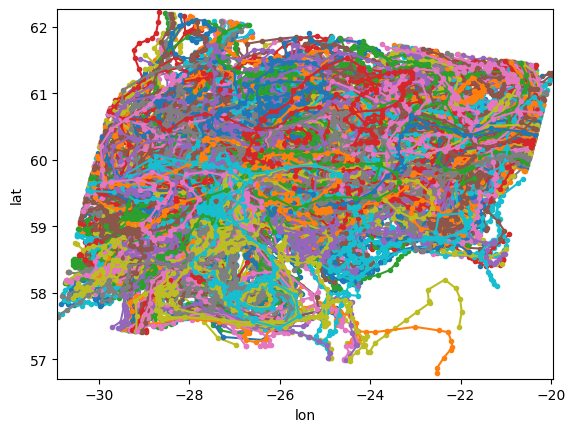

In [275]:
plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.xlabel("lon")
plt.ylabel("lat")
plt.xlim([np.min(lon_rho.values),np.max(lon_rho.values)])
plt.ylim([np.min(lat_rho.values),np.max(lat_rho.values)])
plt.show()

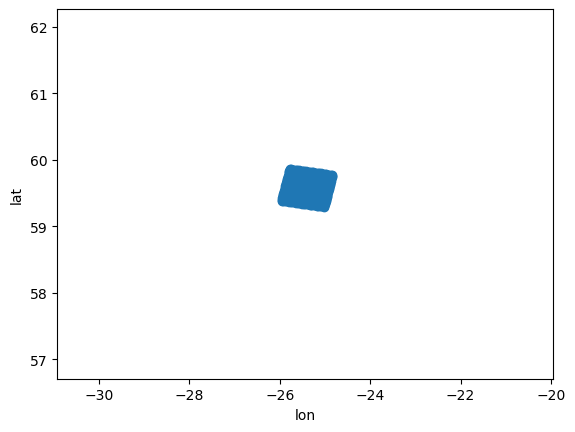

In [276]:
plt.scatter(ds.lon.T[0,:], ds.lat.T[0,:])
plt.xlabel("lon")
plt.ylabel("lat")
plt.xlim([np.min(lon_rho.values),np.max(lon_rho.values)])
plt.ylim([np.min(lat_rho.values),np.max(lat_rho.values)])
plt.show()

/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)


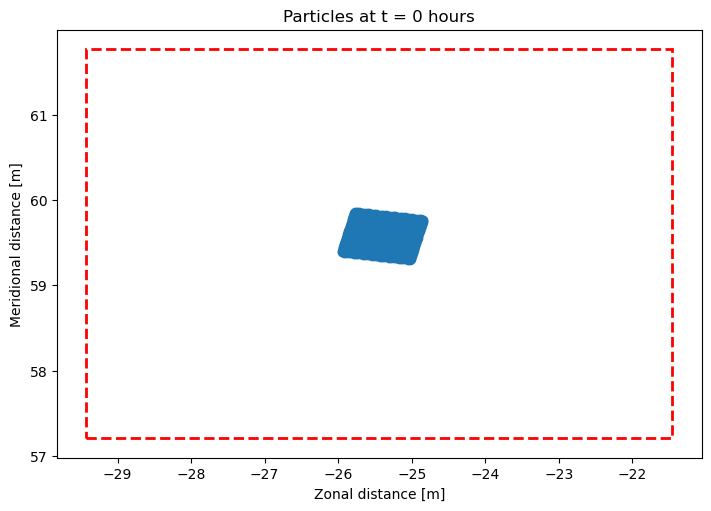

In [279]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches


lon_min = -30.92595646869225 + 1.5
lon_max = -19.9541352315797 - 1.5
lat_min = 56.70597152564239 + 0.5  # 注意：原条件是"+0.5"，但通常下限用减
lat_max = 62.267609501148414 - 0.5  # 原条件是"-0.5"，但通常上限用加

rect = patches.Rectangle(
    (lon_min, lat_min),         # 左下角坐标
    lon_max - lon_min,          # 宽度
    lat_max - lat_min,          # 高度
    linewidth=2, 
    edgecolor='r', 
    facecolor='none',           # 透明填充
    linestyle='--',             # 虚线边框
    label='Target Area'
)

# %% capture
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
ax = fig.add_subplot()
ax.add_patch(rect)

ax.set_ylabel("Meridional distance [m]")
ax.set_xlabel("Zonal distance [m]")

# show only every fifth output (for speed in creating the animation)
timerange = np.unique(ds["time"].values)[::24]

# Indices of the data where time = 0
time_id = np.where(ds["time"] == timerange[0])

sc = ax.scatter(ds["lon"].values[time_id], ds["lat"].values[time_id])

t = str(timerange[0].astype("timedelta64[h]"))
title = ax.set_title(f"Particles at t = {t}")


def animate(i):
    t = str(timerange[i].astype("timedelta64[h]"))
    title.set_text(f"Particles at t = {t}")

    time_id = np.where(ds["time"] == timerange[i])
    sc.set_offsets(np.c_[ds["lon"].values[time_id], ds["lat"].values[time_id]])


anim = FuncAnimation(fig, animate, frames=len(timerange), interval=100)

In [280]:
HTML(anim.to_jshtml())


/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: invalid value encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)

# transform velocity

In [281]:
ue,ve=transunit_spher2flat(ds['ue'].values,ds['ve'].values,ds['lat'].values)
ds['ue'].values=ue
ds['ve'].values=ve

In [282]:
f'{outputwavename[37:-5]}.nc'

'AVISO_pars_P900T91days.nc'

In [283]:
ds.to_netcdf(f'{outputwavename[:-5]}.nc')

/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/hom

In [61]:
# !jupyter nbconvert --to python Parcels_Iceland_wave.ipynb


In [22]:
# (ds['time'].values/1e9/3600)[:,0].astype(int)

In [23]:
# list(ds.data_vars)[10]

In [24]:
# ds['lon'].values.shape[0]

In [25]:
# LONt=np.zeros((ds['lon'].values.shape))
# for ii in range(ds['lon'].values.shape[0]):
#     TT=ds['time'].values[ii,:].astype(int)
#     indice=int(TT[0]/3600/1e9)
#     midvar=np.zeros(TT.shape)*np.nan;
#     midvar[0+indice:]=(ds['lon'].values)[ii,0:(TT.shape[0]-indice)];
#     LONt[ii,:]=midvar;
#     print(ii)
# ds['lon'].values=LONt

In [26]:
# ds[list(ds.data_vars)[0]]

In [27]:
# ds1=ds

In [28]:
# ds1